###confidence interval

**note** :

Some sections of this assignment include additional images, screenshots, diagrams, and explanatory notes that I created to improve my understanding of the concepts.

 These materials were incorporated as part of my learning process and to serve as future study notes. While preparing this assignment, I focused on understanding the concepts rather than only obtaining the final results.

  The supplementary visuals and explanations are included solely for educational purposes and to make the notebook easier to review and learn from later.


Problem Statement:

 Estimate the average durability of print-heads using a 99% confidence interval. Compare the results when the population standard deviation is unknown (t-distribution) and when it is known (Z-distribution).

the scenario which we are working on :

We can't test every print-head, so based on a small sample, what is the best estimate of the true average durability, and how certain are we about that estimate

The flow of how the things work

Real Population

        │
        ▼
Cannot test every print-head

        │
        ▼
Take a random sample (15 print-heads)

        │
        ▼
Collect the durability values

        │
        ▼
Calculate the Sample Mean (x̄)

        │
        ▼
Calculate the Standard Deviation

   ├── Sample SD (s) if σ is unknown

   └── Population SD (σ) if it is given

        │
        ▼
Choose the correct distribution

   ├── t-distribution → σ unknown

   └── Z-distribution → σ known

        │
        ▼
Find the Critical Value (t* or Z*)

        │
        ▼
Calculate the Margin of Error

        │
        ▼
Confidence Interval = Mean ± Margin of Error

        │
        ▼
Interpret the result:

"We are 99% confident that the true average durability
of all print-heads lies within this interval."

what is confidence intervval

A confidence interval is a range of values, calculated from a sample, that is used to estimate the true value of a population while expressing the uncertainty in that estimate

In [ ]:
import numpy as np
from scipy import stats

In [ ]:
data = [
    1.13, 1.55, 1.43, 0.92, 1.25,
    1.36, 1.32, 0.85, 1.07, 1.48,
    1.20, 1.33, 1.18, 1.22, 1.29
]

In [ ]:
#finding the sample size of the data
n = len(data)
print(n)

15


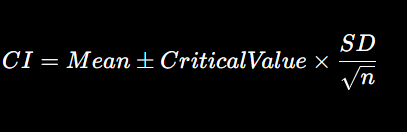

In [ ]:
# caluculating the sample mean
sample_mean = np.mean(data)
sample_mean

np.float64(1.2386666666666666)

here ddof is the degree of freedom and the =1 is the yes we are giving for the ddof

without the ddof the numpy thinks that we are calculating the population mean instead of the sample mean

In [ ]:
# calculating the standard deviation
sample_std = np.std(data,ddof=1)
print(sample_std)

0.19316412956959936


In [ ]:
confidence = 0.99

In [ ]:
t_value = stats.t.ppf(         # ppf means percent point function
    (1 + confidence) / 2,
    df=n-1
)

print(t_value)

2.976842734370834


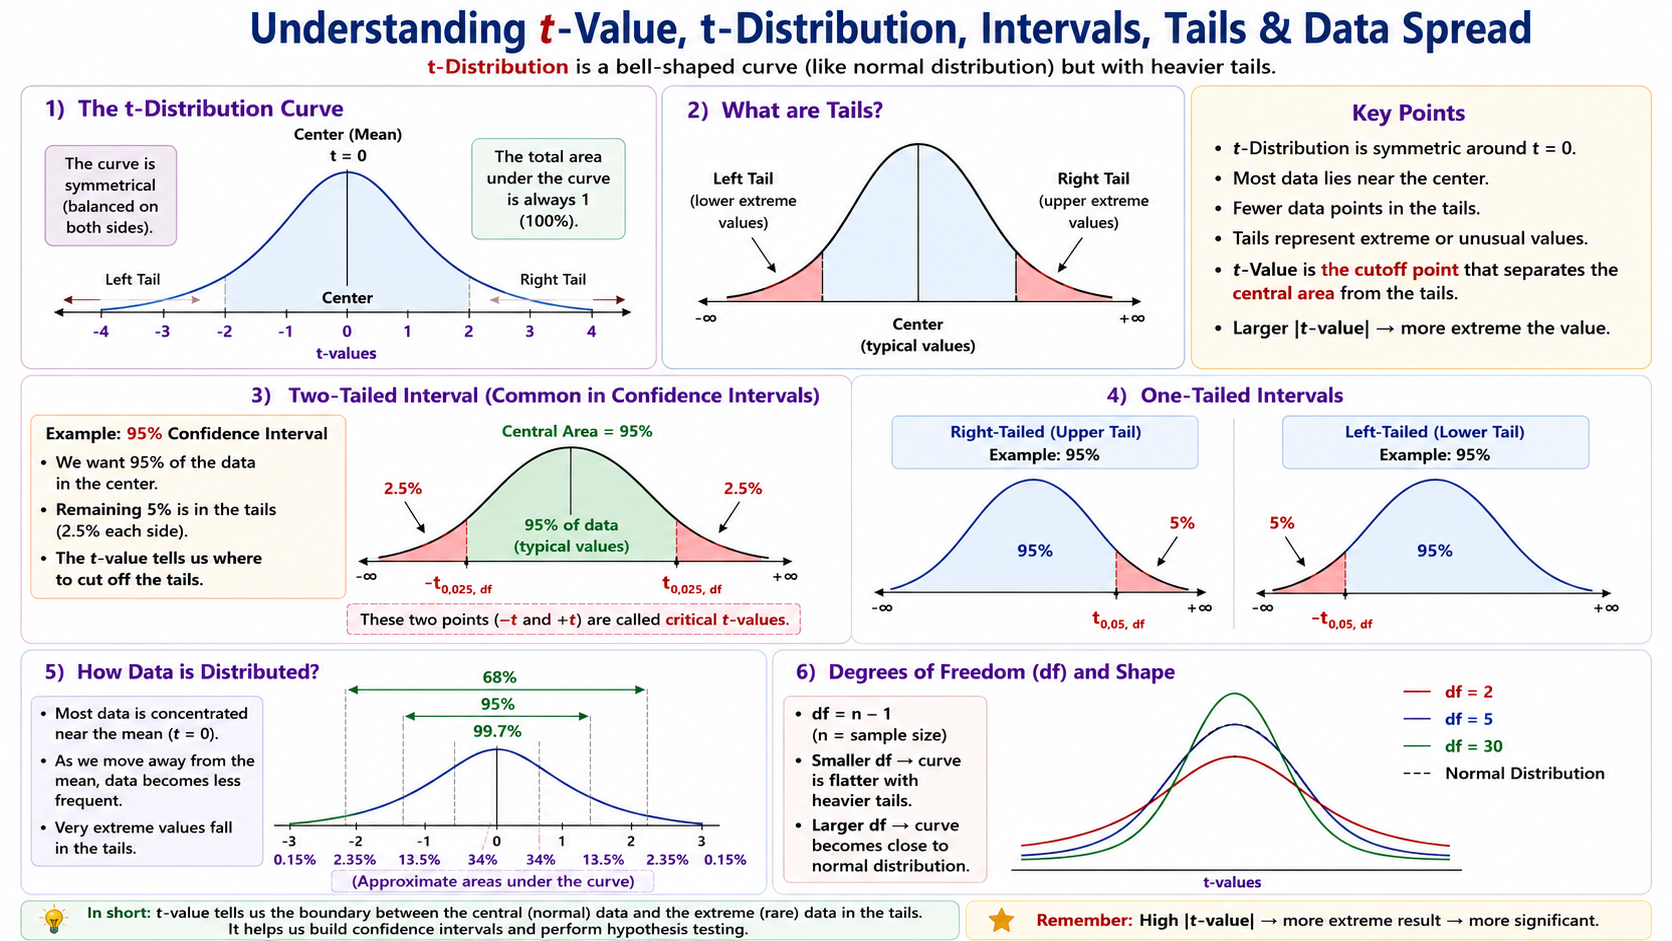

                ALL PRINT-HEADS (Population)
          ┌──────────────────────────────────┐
          │ Millions of print-heads          │
          │ Unknown Mean (μ)                 │
          │ Unknown SD (σ)                   │
          └──────────────────────────────────┘
                         │
                         │ Impossible to test all
                         ▼
              Randomly select 15 print-heads
                         │
                         ▼
        ┌─────────────────────────────────┐
        │ Sample Data                     │
        │1.13 1.55 1.43 ... 1.29          │
        └─────────────────────────────────┘
                         │
                         ▼
         Calculate Sample Statistics
                         │
        ┌───────────────┬─────────────────┐
        │Sample Mean x̄ │ Sample SD (s)    │
        └───────────────┴─────────────────┘
                         │
                         ▼
        Need Critical t-value (Why?)
                         │
                         ▼
      Margin of Error = t × Standard Error
                         │
                         ▼
 Confidence Interval = Mean ± Margin of Error

everything depends on the critical t_value

In [ ]:
from scipy import stats

confidence_level = 0.99          # Assignment asks for 99%
sample_size = 15                 # 15 print-heads

degrees_of_freedom = sample_size - 1

tail_probability = (1 + confidence_level) / 2

critical_t_value = stats.t.ppf(
    tail_probability,
    degrees_of_freedom
)

print("Critical t-value:", critical_t_value)

Critical t-value: 2.976842734370834




For a 99% confidence interval with only 15 observations (df = 14), multiply your Standard Error by 2.9768 to create an interval that accounts for the uncertainty in your estimate.

In [ ]:
standard_error = sample_std/np.sqrt(n)
print('standard_error : ', standard_error)

standard_error :  0.04987476379384733


| Quantity           | Question it answers                                                    |
| ------------------ | ---------------------------------------------------------------------- |
| Mean               | Where is the center of the sample?                                     |
| Standard Deviation | How spread out are the individual print-head values?                   |
| Standard Error     | How accurate is our sample mean as an estimate of the population mean? |
| t-value            | How much extra uncertainty should we allow?                            |


as the sample size increases the standard error decreases

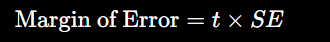

In [ ]:
margin_of_error = critical_t_value * standard_error

print("Margin of Error:", margin_of_error)

Margin of Error: 0.14846932822817596


In [ ]:
lower_limit = sample_mean - margin_of_error
upper_limit = sample_mean + margin_of_error

print(f"99% Confidence Interval: ({lower_limit:.4f}, {upper_limit:.4f})")

99% Confidence Interval: (1.0902, 1.3871)


for z-test

In [ ]:
# Import required libraries
import numpy as np
from scipy import stats

# Step 1: Store the sample data
data = [
    1.13, 1.55, 1.43, 0.92, 1.25,
    1.36, 1.32, 0.85, 1.07, 1.48,
    1.20, 1.33, 1.18, 1.22, 1.29
]


# Step 2: Calculate the sample size
n = len(data)

# Step 3: Calculate the sample mean

sample_mean = np.mean(data)

# Step 4: Set the known population standard deviation

population_std = 0.2

# Step 5: Set the confidence level

confidence_level = 0.99

# Step 6: Calculate the cumulative probability

tail_probability = (1 + confidence_level) / 2

# Step 7: Find the critical Z-value

critical_z_value = stats.norm.ppf(tail_probability)

# Step 8: Calculate the Standard Error

standard_error = population_std / np.sqrt(n)

# Step 9: Calculate Margin of Error

margin_of_error = critical_z_value * standard_error

# Step 10: Calculate Confidence Interval

lower_limit = sample_mean - margin_of_error
upper_limit = sample_mean + margin_of_error

# Step 11: Display all results

print("========== Part B ==========")
print(f"Sample Size (n): {n}")
print(f"Sample Mean (x̄): {sample_mean:.4f}")
print(f"Known Population Standard Deviation (σ): {population_std}")
print(f"Confidence Level: {confidence_level*100:.0f}%")
print(f"Critical Z-value: {critical_z_value:.4f}")  # here .4f is used for the printing of number up to four points in the decimal places
print(f"Standard Error: {standard_error:.4f}")
print(f"Margin of Error: {margin_of_error:.4f}")
print(f"99% Confidence Interval: ({lower_limit:.4f}, {upper_limit:.4f})")

========== Part B ==========
Sample Size (n): 15
Sample Mean (x̄): 1.2387
Known Population Standard Deviation (σ): 0.2
Confidence Level: 99%
Critical Z-value: 2.5758
Standard Error: 0.0516
Margin of Error: 0.1330
99% Confidence Interval: (1.1057, 1.3717)


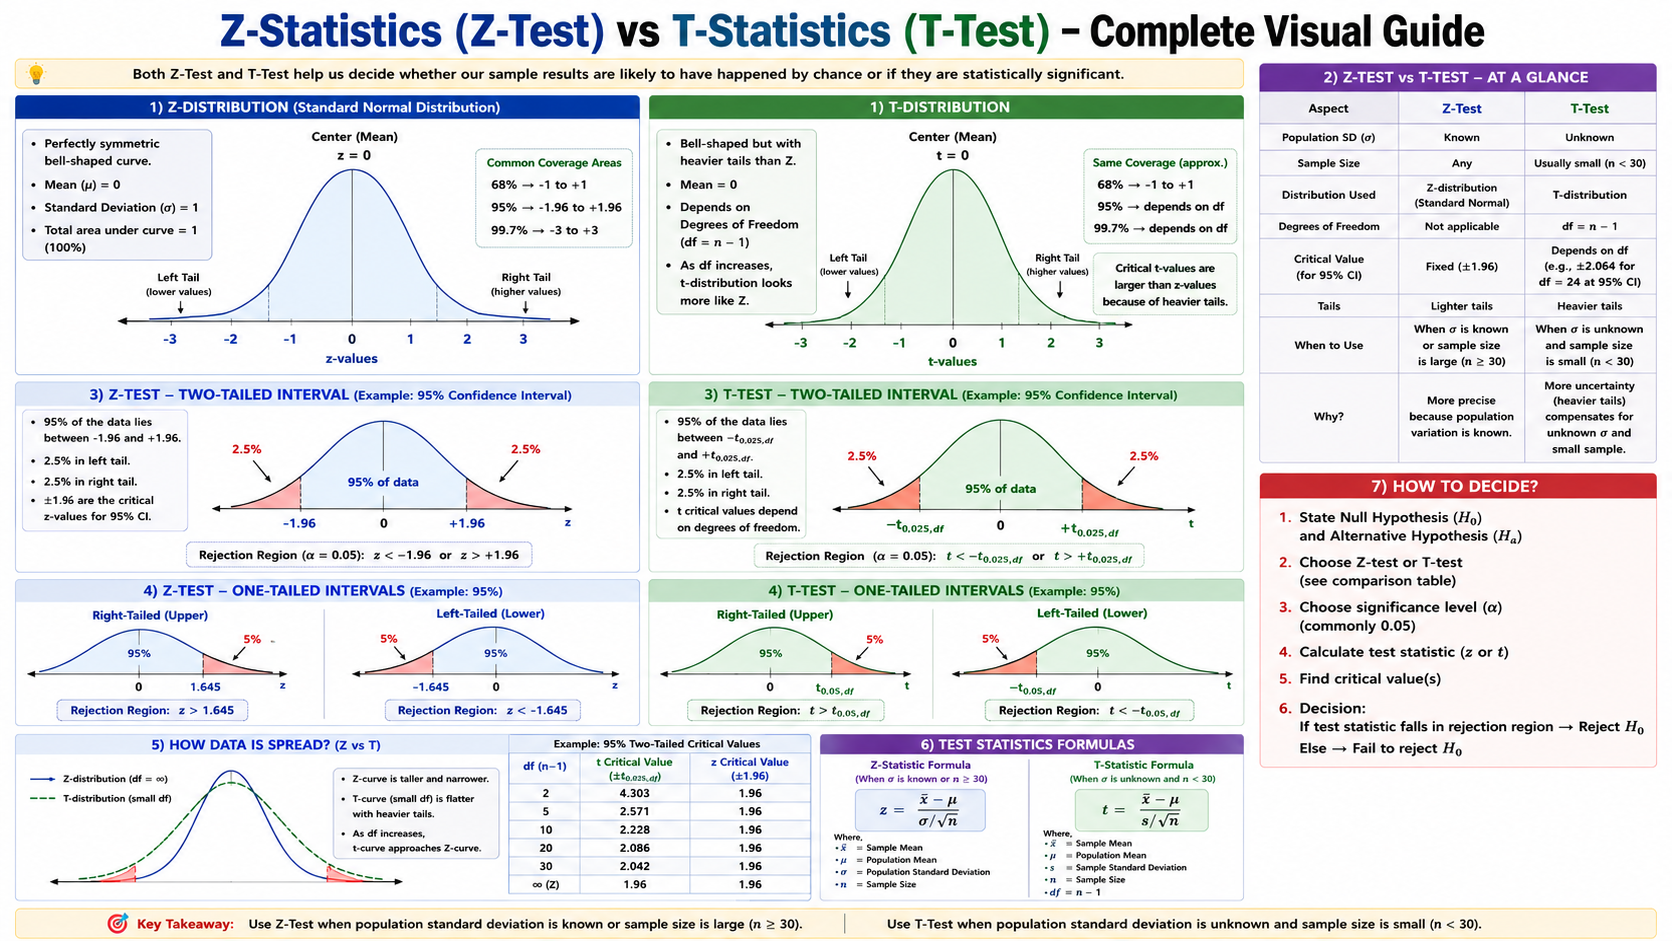

The analysis estimated the average durability of print-heads using a 99% confidence interval. When the population standard deviation was unknown, the t-distribution was used, producing a slightly wider confidence interval due to greater uncertainty. When the population standard deviation was known, the Z-distribution was used, resulting in a slightly narrower confidence interval. This demonstrates how knowledge of the population standard deviation affects the precision of the estimate.

###hypothesis testing

work flow :

                 BUSINESS PROBLEM
                        │
                        ▼
      Someone makes a claim (Hypothesis)
                        │
                        ▼
          Collect Sample Data
                        │
                        ▼
        Compare Sample vs Expected
                        │
                        ▼
      Is the difference BIG or SMALL?
                        │
                        ▼
      Measure it using Z-score or t-score
                        │
                        ▼
        Compare with Critical Value
                        │
                        ▼
           Make a Decision
                        │
                        ▼
         Write Business Conclusion

**Stating the hypothesis**


The company says:  The cost model is correct.

*This becomes the Null Hypothesis (H₀).*

The restaurant owners say:  Costs are higher.

*This becomes the Alternative Hypothesis (H₁)*.



 Cost Model

W=1000+5X

This means:

Fixed cost = 1000
Every additional unit increases the cost by 5.

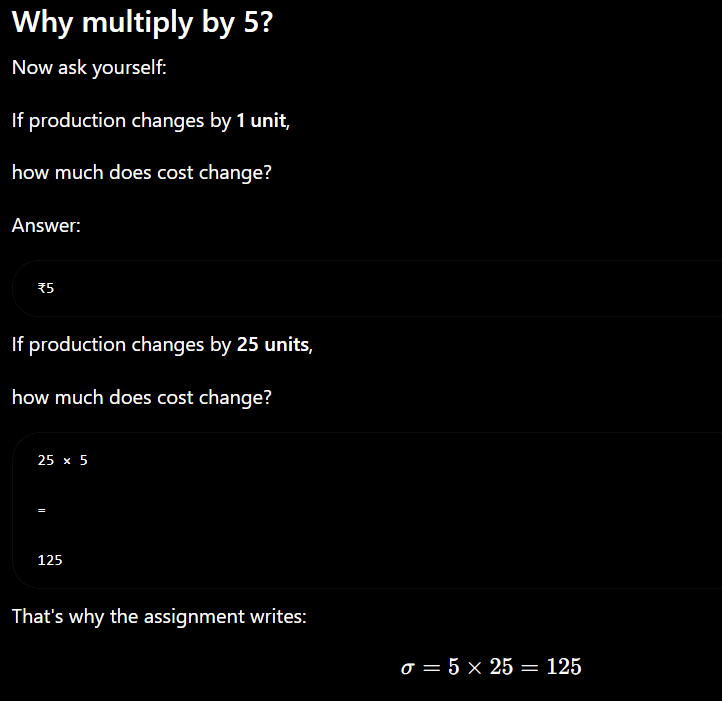

                     Company

                  H₀ : μ = 4000
                        │
                        │
                        │
                Is this still true?
                        │
                        ▼
              Collect Sample Data
                        │
                        ▼
        Restaurant Owners Claim

                 H₁ : μ > 4000

Assume H₀

↓

Collect Evidence

↓

Enough Evidence?

↓

Yes

Reject H₀

↓

No

Fail to Reject H₀

How do we decide whether the sample supports the restaurant owners' claim?

The answer is the Test Statistic (Z-statistic).

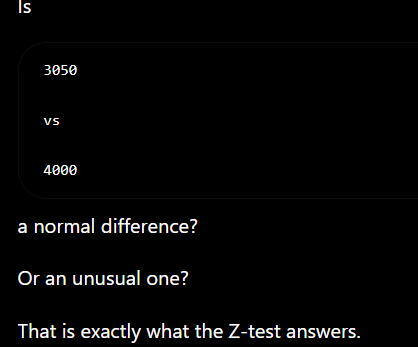

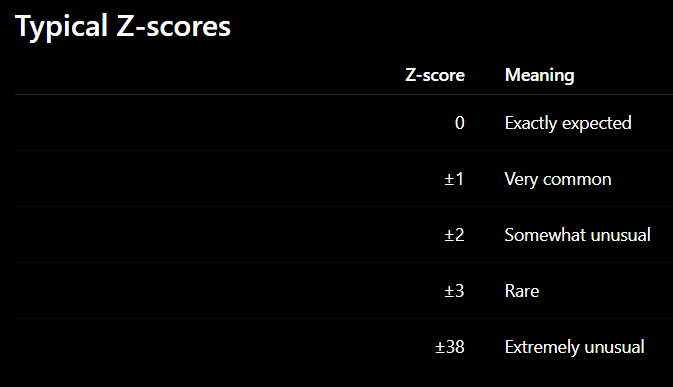

In [ ]:

# HYPOTHESIS TESTING ASSIGNMENT


import numpy as np
from scipy import stats


# Step 1: Given Data


sample_mean = 3050          # Sample mean weekly cost
sample_size = 25            # Number of restaurants

X = 600                     # Average units produced

population_std = 5 * 25     # σ = 5 × 25 = 125

alpha = 0.05                # Significance level


# Step 2: Calculate Theoretical Mean or expected mean(4000)
# W = 1000 + 5X


theoretical_mean = 1000 + (5 * X)

print("Theoretical Mean (μ):", theoretical_mean)


# Step 3: State the Hypotheses


print("\nHypotheses")

print("H0: μ <= 4000")
print("H1: μ > 4000")


# Step 4: Calculate Standard Error


standard_error = population_std / np.sqrt(sample_size)

print("\nStandard Error:", standard_error)


# Step 5: Calculate Test Statistic (Z)

                                                                 # The Z-score tells us:
                                                                         #How many Standard Errors away is the sample from the expected value?
z_statistic = (sample_mean - theoretical_mean) / standard_error

print("\nZ Statistic:", z_statistic)


# Step 6: Critical Value
# Right-tailed test : because we are checking the values which are gerater than the mean Or expected mean


critical_value = stats.norm.ppf(1 - alpha)

print("\nCritical Value:", critical_value)


# Step 7: P-value


p_value = 1 - stats.norm.cdf(z_statistic)

print("\nP-value:", p_value)


# Step 8: Decision


print("\nDecision")

if z_statistic > critical_value:
    print("Reject the Null Hypothesis (H0)")
else:
    print("Fail to Reject the Null Hypothesis (H0)")


# Step 9: Conclusion


print("\nConclusion")

if z_statistic > critical_value:
    print("There is sufficient evidence to support the restaurant owners' claim that")
    print("the weekly operating costs are higher than the theoretical model.")
else:
    print("There is insufficient evidence to support the restaurant owners' claim.")
    print("The available sample does not provide enough evidence that")
    print("weekly operating costs are higher than predicted.")

Theoretical Mean (μ): 4000

Hypotheses
H0: μ <= 4000
H1: μ > 4000

Standard Error: 25.0

Z Statistic: -38.0

Critical Value: 1.6448536269514722

P-value: 1.0

Decision
Fail to Reject the Null Hypothesis (H0)

Conclusion
There is insufficient evidence to support the restaurant owners' claim.
The available sample does not provide enough evidence that
weekly operating costs are higher than predicted.
